# Projet de Machine Learning (Python)

## Création des échantillons train et test

**Divisez le jeu de données en un échantillon d’apprentissage et un échantillon test. Vous prendrez un pourcentage de 20% pour l’échantillon test. Pourquoi cette étape est-elle nécessaire lorsque nous nous concentrons sur les performances des algorithmes ?**

Le fait d'entraîner et de tester le modèle sur deux échantillons distincts permet de tester ses véritables performances face à des données nouvelles. Si l'on testait sur l'échantillon d'apprentissage, les performances seraient artificiellement meilleures et nous ne pourrions pas détecter un surapprentissage éventuel.

In [4]:
import pandas as pd
import numpy as np

seed = 42  #seed pour la reproductibilité

In [5]:
df = pd.read_csv('healthcare_synthetic_data.csv')  # Création du dataframe
print(f"Dimensions : {df.shape}") # Affichage de ses dimensions
df.head() # Affichage des 5 premières lignes du df

Dimensions : (15000, 19)


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


In [6]:
# Nous remarquons que les variables qualitatives sont deja encodées numériquement (en états 0,1,2), nous n'avons donc rien à changer ici.

# Suppression de Patient_ID car inutile dans notre tâche de classification
df = df.drop(columns=['Patient_ID'])

# Création de listes par type de variable
quant_vars = ['Age','Height_cm','Weight_kg','BMI','Systolic_BP','Diastolic_BP',
              'Cholesterol_Total','Cholesterol_LDL','Cholesterol_HDL',
              'Fasting_Blood_Sugar','Stress_Level','Sleep_Hours']

qual_vars  = ['Gender','Smoking_Status','Alcohol_Consumption',
              'Physical_Activity_Level','Family_History']

var_cls = 'Heart_Disease_Risk'  #Variable à classifier
var_reg = 'Cholesterol_LDL'  #Variable pour la régression

# Affichage des différentes variables
print("Variables quantitatives :", quant_vars)
print("\n")
print("Variables qualitatives (encodées) :", qual_vars)
print("\n")
print("Cibles :", var_cls, '|', var_reg)

Variables quantitatives : ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL', 'Cholesterol_HDL', 'Fasting_Blood_Sugar', 'Stress_Level', 'Sleep_Hours']


Variables qualitatives (encodées) : ['Gender', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Family_History']


Cibles : Heart_Disease_Risk | Cholesterol_LDL


In [7]:
# Division des données en train (80%) et test (20%) pour la CLASSIFICATION

from sklearn.model_selection import train_test_split
df_cls = df.copy()  # Création d'un dataframe spécifique à la classification (protection sur df)

# Création d'une liste des variables pour la classification (toutes les variables sauf 'Heart_Disease_Risk')
variables_cls = [c for c in df_cls.columns if c != var_cls]

X_cls = df_cls[variables_cls] # Création d'un dataframe qui ne contient que les variables utiles à la tâche de classification
y_cls = df_cls[var_cls] # Création d'un dataframe d'une colonne qui contient la variable à classifier ('Heart_Disease_Risk')

# Division 80/20
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.20, random_state=seed, stratify=y_cls)
                                #stratify=y_cls permet de garantir que chaque classe est bien représentée dans le train et test

In [8]:
#Division des données en train (80%) et test (20%) pour la RÉGRESSION

from sklearn.model_selection import train_test_split
df_reg = df.copy() # Création d'un dataframe spécifique à la régression (protection sur df)

# Création d'une liste des variables pour la régression (toutes les variables sauf 'Heart_Disease_Risk' et 'Cholesterol_LDL')
variables_reg = [c for c in df_cls.columns if c != var_cls and c!=var_reg]


X_reg = df_reg[variables_reg] # Création d'un dataframe qui ne contient que les variables utiles à la tâche de régression
y_reg = df_reg[var_reg] # Création d'un dataframe d'une colonne qui contient la variable à prédire par régression ('Cholesterol_LDL')

# Division 80/20
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.20, random_state=seed)
                                                        # On ne peut pas utiliser stratify ici car var_reg est continue (régression)


Avant de commencer les tâches de classification et de régression, nous devons **standardiser** nos variables explicatives.

En effet, puisque que nos variables ont des ordres de grandeur et des unités très différents, nous devons les ramener à la même échelle. Sans cette étape de standardisation, les méthodes basées sur les distances (comme SVM) ou sur la descente de gradient (comme la Régression Logistique ou Ridge) accorderaient artificiellement plus de poids aux variables ayant les plus grandes valeurs.

In [9]:
from sklearn.preprocessing import StandardScaler 

#Classification
scaler = StandardScaler()  
scaler.fit(X_train_c) # Calcul de la moyenne et de l'écart-type de chaque variables du train (évite la fuite de données)
Xr_train_c = scaler.transform(X_train_c) # On applique la transformation (. - moyenne_var)/std sur le train
Xr_test_c = scaler.transform(X_test_c) # On applique la transformation (. - moyenne_var)/std sur le test



#Régression
scaler = StandardScaler()  
scaler.fit(X_train_r)  
Xr_train_r = scaler.transform(X_train_r)
Xr_test_r = scaler.transform(X_test_r)

## A. Modèles de classification pour la variable 'Heart_Disease_Risk'

### I. Modèles linéaires

#### I. a) Régression logistique (GLM)

In [10]:
#On commence par un GLM classique pour la classification : la régression logistique.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Grille d'hyperparamètres (C = 1/λ)
param=[{"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}]
logit = GridSearchCV(LogisticRegression(solver="liblinear"), param,cv=5,n_jobs=-1)  #=> en sklearn=1.8.0, le default est d'avoir une pénalité l2
                                        #Pour avoir une logit pure, il faut absolument mettre C=np.inf et donc pas de GridSearch.....
logitOpt=logit.fit(Xr_train_c, y_train_c)  # GridSearchCV est lui-même un estimateur=>Je sais pas trop pk on dit ca la....

logitOpt=LogisticRegression(C=np.inf).fit(Xr_train_c, y_train_c) # Logit pure

/home/astrid/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


In [11]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

# Prédictions
y_pred_logit = logitOpt.predict(Xr_test_c)

#Table de résultats
table = pd.crosstab(y_test_c, y_pred_logit,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

#print(f"Meilleur C (Logit): {logitOpt.best_params_['C']}")
#print(f"Accuracy CV (train, Logit): {logitOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, Logit) : {accuracy_score(y_test_c, y_pred_logit)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_logit)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_logit)*100:.4f}%")

Prédiction,Sain (0),Risque (1)
Réalité,,
Sain (0),1376,316
Risque (1),469,839


Accuracy globale (test, Logit) : 73.8333%
Rappel (Détection vrais malades) : 64.1437%
Précision (Fiabilité des alertes) : 72.6407%


La régression logistique aboutit en un classificateur qui a une **performance globale** de 73.83%. C'est un très bon score, surtout pour des données médicales (même si elles sont synthétiques) où le hasard joue souvent une grande part.
Nous remarquons cependant que le **rappel** (la détection des vrais malades) n'est que de 64.14%, ce qui est plus faible que la **précision** (la fiabilité des alertes) qui est de 72.64%. Concrètement, notre modèle génère 469 Faux Négatifs, ce qui n'est pas satisfaisant dans un contexte médical. 

Dans le secteur médical, il est préférable d'avoir un fort rappel car cela permet de détecter plus de malade, quitte à lancer des fausses alertes plus souvent. Il serait donc préférable de dégrader légèrement la précision du modèle afin d'augmenter le rappel.

#### I. b) Ridge (pénalisation sans sélection de variables)

In [12]:
#On continue sur de la pénalisation sans sélection de variables : Ridge

# Grille d'hyperparamètres (C = 1/λ)
param = {"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}
# ridge = GridSearchCV(LogisticRegression(penalty="l2", solver="liblinear"),param,cv=5,n_jobs=-1)
                                # En sklearn 1.8, penalty a été deprecated => penalty='l2'~l1_ratio=0 (default), penalty='l1'~l1_ratio=1, penalty='elasticnet'~l1_ratio=any_float
ridge = GridSearchCV(LogisticRegression(l1_ratio=0, solver="liblinear"),param,cv=5,n_jobs=-1)
ridgeOpt = ridge.fit(Xr_train_c, y_train_c)


In [13]:
# Prédictions
y_pred_ridge = ridgeOpt.best_estimator_.predict(Xr_test_c)

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_ridge,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleur C (Ridge): {ridgeOpt.best_params_['C']}")
print(f"Accuracy CV (train, Ridge): {ridgeOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, Ridge) : {accuracy_score(y_test_c, y_pred_ridge)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_ridge)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_ridge)*100:.4f}%")

Prédiction,Sain (0),Risque (1)
Réalité,,
Sain (0),1375,317
Risque (1),467,841


Meilleur C (Ridge): 0.01
Accuracy CV (train, Ridge): 73.8417%
Accuracy globale (test, Ridge) : 73.8667%
Rappel (Détection vrais malades) : 64.2966%
Précision (Fiabilité des alertes) : 72.6252%


L'ajout d'une pénalité L² (Ridge) aboutit en un classificateur qui a une **performance globale** de 73.87%, ce qui est très légèrement supérieur à la régression logistique classique.
Nous remarquons là encore que le **rappel** (la détection des vrais malades) est plus faible que la **précision** (la fiabilité des alertes): 64.30% contre 72.63%. 

Nous remarquons cependant une légère amélioration du rappel grâce au Ridge. En effet, le nombre de Faux Négatifs a été réduit à 467, contre 469 pour le modèle Logit pur. Concrètement le modèle Ridge a permis de détecter correctement 2 malades supplémentaires par rapport au modèle de régression logistique pure

Coefficients de Ridge : [ 2.31616900e-01 -3.08950223e-02 -3.66611940e-02  9.74895149e-02
  1.13224169e-01  3.11639173e-01  1.13683956e-04  8.14219025e-03
  1.59726676e-01 -3.79377015e-02  2.87969283e-01  8.60591446e-01
 -1.14898533e-02 -4.24968474e-01  4.97882752e-01  2.76442781e-01
 -8.63310673e-02]


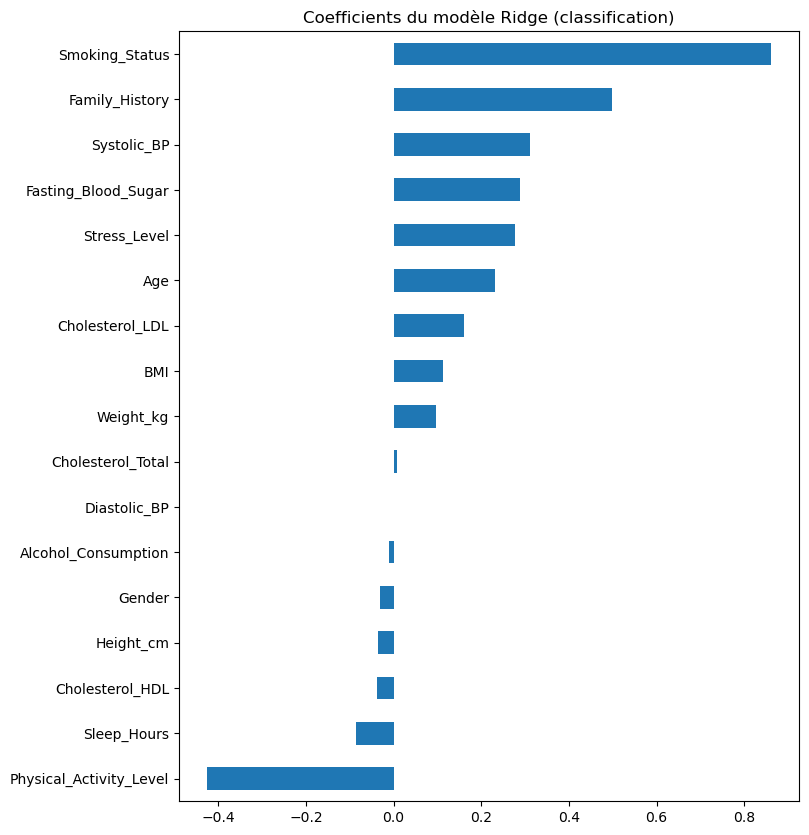

In [14]:
import matplotlib.pyplot as plt

# Coefficients du meilleur modèle
ridgeCoef = ridgeOpt.best_estimator_.coef_[0]
print(f"Coefficients de Ridge : {ridgeCoef}")

coef = pd.Series(ridgeCoef, index=X_train_c.columns)


# Visualisation
imp_coef = coef.sort_values()
plt.figure(figsize=(8,10))
imp_coef.plot(kind="barh")
plt.title("Coefficients du modèle Ridge (classification)")
plt.show()

L'affichage des coefficients du modèle Ridge illustre parfaitement le fonctionnement mathématique de la pénalisation L². On observe que l'algorithme a écrasé l'impact de certaines variables en rapprochant fortement leurs coefficients de zéro, mais n'en a annulé strictement aucune. Le modèle Ridge stabilise donc les poids pour éviter le surapprentissage, mais ne fait pas de sélection de variables : toutes les données d'origine sont conservées pour la prédiction finale.

#### I. c) LASSO (pénalisation avec sélection de variables)

In [15]:
#On continue sur de la pénalisation avec sélection de variables : LASSO

# Grille d'hyperparamètres
param = {"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}
# lasso = GridSearchCV(LogisticRegression(penalty="l1", solver="liblinear"),param,cv=5,n_jobs=-1)

lasso = GridSearchCV(LogisticRegression(l1_ratio=1, solver="liblinear"),param,cv=5,n_jobs=-1)
lassoOpt = lasso.fit(Xr_train_c, y_train_c)

In [19]:
# Prédictions
y_pred_lasso = lassoOpt.best_estimator_.predict(Xr_test_c)

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_lasso,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleur C (LASSO): {lassoOpt.best_params_['C']}")
print(f"Accuracy CV (train, LASSO): {lassoOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, LASSO) : {accuracy_score(y_test_c, y_pred_lasso)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_lasso)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_lasso)*100:.4f}%")

Prédiction,Sain (0),Risque (1)
Réalité,,
Sain (0),1373,319
Risque (1),462,846


Meilleur C (LASSO): 0.05
Accuracy CV (train, LASSO): 73.8417%
Accuracy globale (test, LASSO) : 73.9667%
Rappel (Détection vrais malades) : 64.6789%
Précision (Fiabilité des alertes) : 72.6180%


L'utilisation d'une pénalité L¹ (LASSO) aboutit en un classificateur qui a une **performance globale** de 73.97%, ce qui est mieux que celle obtenue par le modèle Ridge.
Nous remarquons là encore que le **rappel** (la détection des vrais malades) est plus faible que la **précision** (la fiabilité des alertes): 64.68% contre 72.62%. 

Nous remarquons cependant une réelle amélioration du rappel par rapport au modèle Ridge. En effet, le nombre de Faux Négatifs a été réduit à 462, contre 467 pour Ridge. Concrètement le modèle LASSO a permis de détecter correctement 5 malades supplémentaires par rapport au modèle Ridge. En contrepartie, le modèle a généré 2 fausses alertes de plus (les Vrais Négatifs passent de 1375 à 1373). C'est l'illustration parfaite du compromis médical évoqué précédemment : le LASSO a sacrifié une infime part de sa précision sur les patients sains, ce qui est un prix tout à fait acceptable pour réussir à sauver 5 patients à risque supplémentaires.

Coefficients de LASSO : [ 0.23624109 -0.00735427  0.          0.01218006  0.18459222  0.32337185
  0.          0.          0.16695601 -0.02479709  0.29755865  0.89950309
 -0.00308472 -0.44310445  0.51899169  0.28477903 -0.08312564]

Lasso conserve 14 variables et en supprime 3


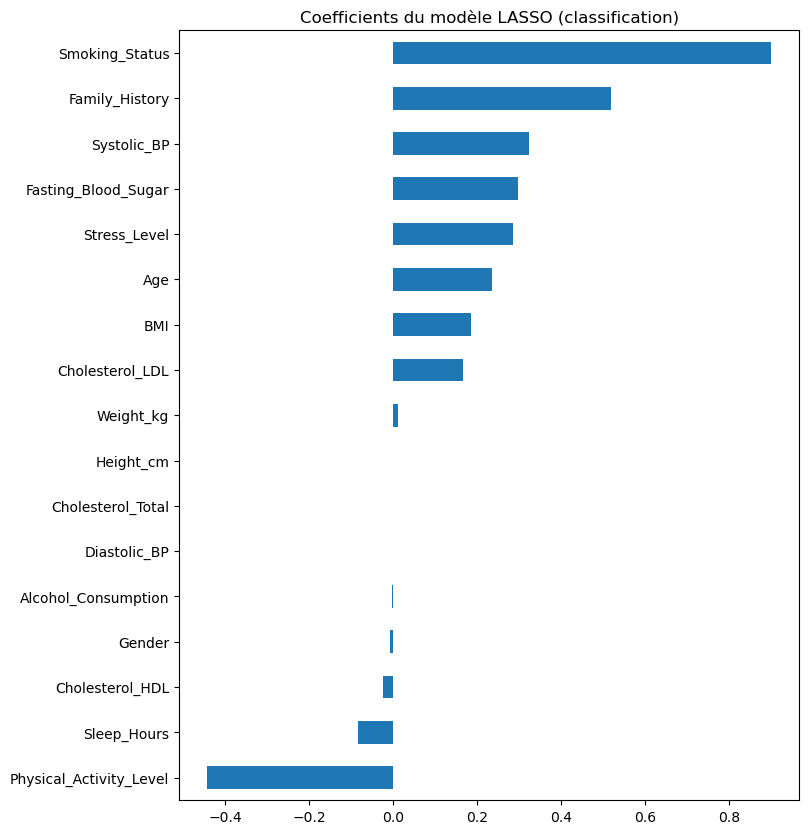

In [17]:
# Coefficients du meilleur modèle
lassoCoef = lassoOpt.best_estimator_.coef_[0]
print(f"Coefficients de LASSO : {lassoCoef}")

coef = pd.Series(lassoCoef, index=X_train_c.columns)

print("\nLasso conserve", sum(coef != 0),
      "variables et en supprime", sum(coef == 0))

# Visualisation
imp_coef = coef.sort_values()
plt.figure(figsize=(8,10))
imp_coef.plot(kind="barh")
plt.title("Coefficients du modèle LASSO (classification)")
plt.show()

L'affichage des coefficients du modèle LASSO illustre parfaitement le fonctionnement mathématique de la pénalisation L¹. On observe que l'algorithme a écrasé l'impact de certaines variables en fixant leur coefficient à zéro, il a donc fait une sélection de variables.

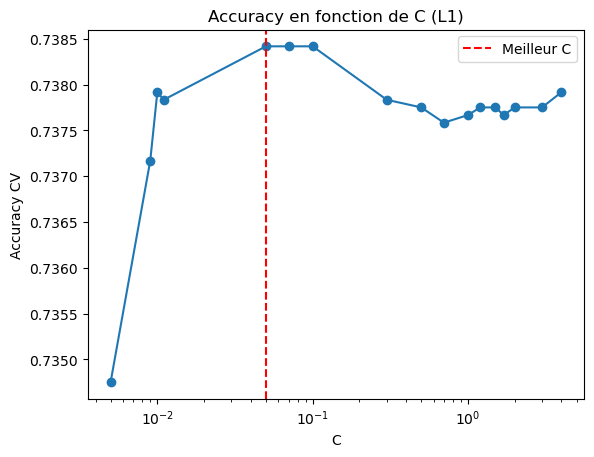

In [18]:
# Affichage de l'accuracy CV en fonction de la valeur de C
mean_scores = lasso.cv_results_['mean_test_score']
Cs = param["C"]

plt.plot(Cs, mean_scores, marker='o')
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Accuracy CV")
plt.title("Accuracy en fonction de C (L1)")
plt.axvline(lassoOpt.best_params_['C'], color='red', linestyle='--', label='Meilleur C')
plt.legend()
plt.show()



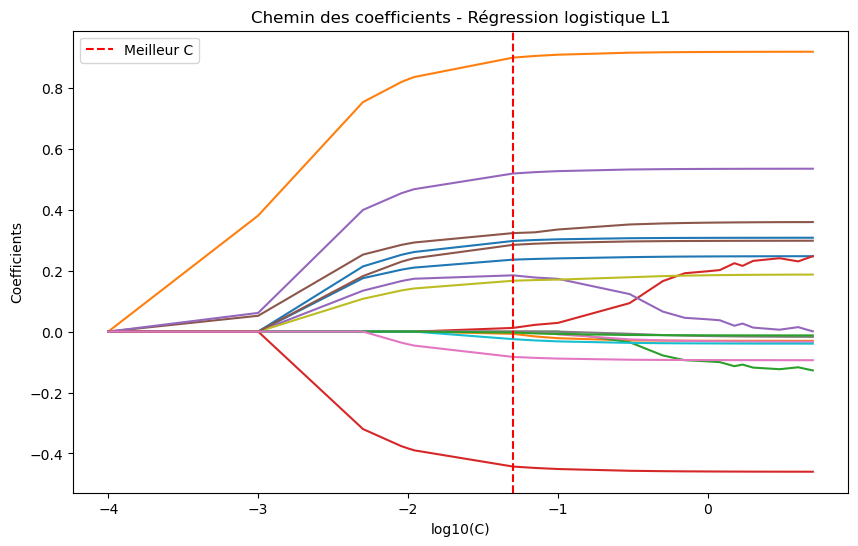

In [20]:
# Nous sommes obligés d'entraîner à nouveau un modèle afin de récupérer les valeurs des coefficients pour chaque C
Cs = [0.0001,0.001,0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4,4.5,5]  #on rajoute 0.0001,0.001, et ,4.5,5 pour la visualisation
coefs = []

for C in Cs:
    clf = LogisticRegression(l1_ratio=1, solver="liblinear", C=C)
    clf.fit(Xr_train_c, y_train_c)
    coefs.append(clf.coef_.ravel())

coefs = np.array(coefs)

plt.figure(figsize=(10,6))
plt.plot(np.log10(Cs), coefs)
plt.xlabel("log10(C)")
plt.ylabel("Coefficients")
plt.title("Chemin des coefficients - Régression logistique L1")
plt.axvline(np.log10(lasso.best_params_['C']), color='red', linestyle='--', label='Meilleur C')
plt.legend()
plt.show()


Pour des valeurs de C très faibles (donc pour une très forte pénalité), tous les coefficients sont nuls. A mesure que C croît, les coefficients des variables grandissent jusqu'à se stabiliser autour d'une certaine valeur pour certains. Nous remarquons que certains coefficients sont restés nuls, ce qui est cohérent puisque LASSO fait une sélection de variables.

#### I. d) Elastic Net

In [34]:
# Grille d'hyperparamètres (C = 1/λ)
param = {"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4], "l1_ratio":[0.1,0.3,0.5,0.6,0.8,0.85,0.9,0.95]}

ela = GridSearchCV(LogisticRegression(solver="saga"),param,cv=5,n_jobs=-1)

elaOpt = ela.fit(Xr_train_c, y_train_c)

In [35]:
# Prédictions
y_pred_ela = elaOpt.best_estimator_.predict(Xr_test_c)

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_ela,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleurs hyperparamètres (Elastic Net): {elaOpt.best_params_}")
print(f"Accuracy CV (train, Elastic Net): {elaOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, Elastic Net) : {accuracy_score(y_test_c, y_pred_ela)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_ela)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_ela)*100:.4f}%")

Prédiction,Sain (0),Risque (1)
Réalité,,
Sain (0),1375,317
Risque (1),466,842


Meilleurs hyperparamètres (Elastic Net): {'C': 0.05, 'l1_ratio': 0.85}
Accuracy CV (train, Elastic Net): 73.9083%
Accuracy globale (test, Elastic Net) : 73.9000%
Rappel (Détection vrais malades) : 64.3731%
Précision (Fiabilité des alertes) : 72.6488%


Combiner les pénalités L¹ et L² grâce à Elastic Net aboutit en un classificateur qui a une **performance globale** de 73.9%, ce qui est moins bien que celle obtenue par le modèle LASSO.
Nous remarquons là encore que le **rappel** (la détection des vrais malades) est plus faible que la **précision** (la fiabilité des alertes): 64.37% contre 72.65%. 

Nous remarquons une légère amélioration de la précision par rapport à LASSO: 72.65% contre 72.62%. Concrètement, le modèle Elastic Net génère 2 fausses alertes (Faux Positifs) de moins que LASSO. Cependant, nous observons une nette dégradation du rappel par rapport au modèle LASSO. En effet, le nombre de Faux Négatifs est de à 466, contre 462 pour LASSO. Concrètement le modèle Elastic Net n'a pas détecté 4 malades de plus que le modèle LASSO.

Enfin, nous remarquons que le modèle optimal Elastic Net se comporte à 85% comme le modèle LASSO (l1_ratio). Cela confirme que pour nos données, l'approche par sélection de variables est la plus pertinente. Cette cohérence est d'ailleurs illustrée par le fait que les coefficients annulés par l'Elastic Net sont identiques à ceux identifiés par le LASSO.

Coefficients de Elastic Net : [ 0.23723882 -0.01214649  0.          0.01823805  0.18006962  0.32448761
  0.          0.          0.16803315 -0.02711287  0.29893257  0.90068157
 -0.00453838 -0.44491657  0.52022239  0.28640379 -0.08459772]

Elastic Net conserve 14 variables et en supprime 3


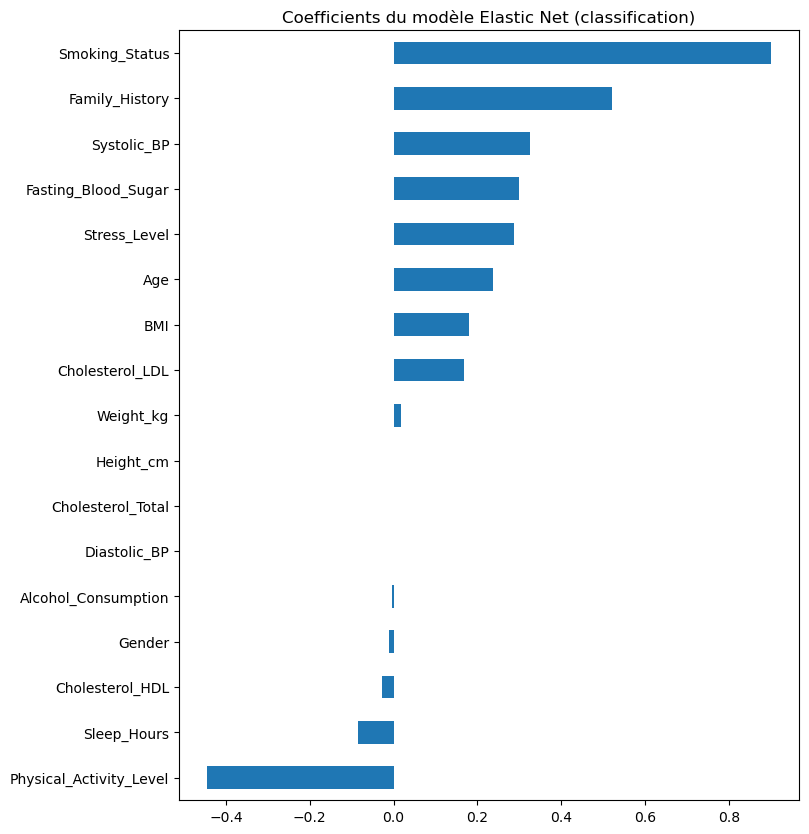

In [36]:
# Coefficients du meilleur modèle
elaCoef = elaOpt.best_estimator_.coef_[0]
print(f"Coefficients de Elastic Net : {elaCoef}")

coef = pd.Series(elaCoef, index=X_train_c.columns)

print("\nElastic Net conserve", sum(coef != 0),
      "variables et en supprime", sum(coef == 0))


# Visualisation
imp_coef = coef.sort_values()
plt.figure(figsize=(8,10))
imp_coef.plot(kind="barh")
plt.title("Coefficients du modèle Elastic Net (classification)")
plt.show()

### II. Support Vector

Pour la tâche de classification, nous ne pouvons utiliser que SVC et non SVR. Nous testons tous les noyaux disponibles.

#### II. a) SVM avec kernel RBF

In [37]:
from sklearn.svm import SVC

param=[{"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}]
svm= GridSearchCV(SVC(kernel="rbf"),param,cv=10,n_jobs=-1)
svmOpt=svm.fit(Xr_train_c, y_train_c)

KeyboardInterrupt: 

In [18]:
# Prédictions
y_pred_rbf = svmOpt.predict(Xr_test_c)

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_rbf,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleur C (SVM RBF): {svmOpt.best_params_['C']}")
print(f"Accuracy CV (train, SVM RBF): {svmOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, SVM RBF) : {accuracy_score(y_test_c, y_pred_rbf)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_rbf)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_rbf)*100:.4f}%")

Heart_Disease_Risk     0    1
row_0                        
0                   1384  493
1                    308  815


#### II. b) SVM avec kernel linéaire

In [19]:
param=[{"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}]
svm_l= GridSearchCV(SVC(kernel="linear"),param,cv=10,n_jobs=-1)
svm_lOpt=svm_l.fit(Xr_train_c, y_train_c)

Meilleur C (SVM Linéaire): 0.3
Accuracy CV (train, SVM linéaire): 73.2250%


In [20]:
# Prédictions
y_pred_l = svm_lOpt.predict(Xr_test_c)

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_l,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleur C (SVM Linéaire): {svm_lOpt.best_params_['C']}")
print(f"Accuracy CV (train, SVM Linéaire): {svm_lOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, SVM Linéaire) : {accuracy_score(y_test_c, y_pred_l)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_l)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_l)*100:.4f}%")

Heart_Disease_Risk     0    1
row_0                        
0                   1361  492
1                    331  816


#### II. c) SVM avec kernel polynomial

In [21]:
param=[{"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}]
svm_p= GridSearchCV(SVC(kernel="poly"),param,cv=10,n_jobs=-1)
svm_pOpt=svm_p.fit(Xr_train_c, y_train_c)

Meilleur C (SVM Polynomial): 0.3
Accuracy CV (train, SVM Polynomial): 73.1667%


In [22]:
# Prédictions
y_pred_p = svm_pOpt.predict(Xr_test_c)

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_p,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleur C (SVM Polynomial): {svm_pOpt.best_params_['C']}")
print(f"Accuracy CV (train, SVM Polynomial): {svm_pOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, SVM Polynomial) : {accuracy_score(y_test_c, y_pred_p)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_p)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_p)*100:.4f}%")

Heart_Disease_Risk     0    1
row_0                        
0                   1409  549
1                    283  759


#### II. d) SVM avec kernel sigmoid

In [23]:
param=[{"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}]
svm_s= GridSearchCV(SVC(kernel="sigmoid"),param,cv=10,n_jobs=-1)
svm_sOpt=svm_s.fit(Xr_train_c, y_train_c)

Meilleur C (SVM Sigmoid): 0.011
Accuracy CV (train, SVM Sigmoid): 73.0083%


In [24]:
# Prédictions
y_pred_s = svm_sOpt.predict(Xr_test_c)

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_s,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleur C (SVM Sigmoid): {svm_sOpt.best_params_['C']}")
print(f"Accuracy CV (train, SVM Sigmoid): {svm_sOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, SVM Sigmoid) : {accuracy_score(y_test_c, y_pred_s)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_s)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_s)*100:.4f}%")

Heart_Disease_Risk     0    1
row_0                        
0                   1407  541
1                    285  767


Nous remarquons que les résulats obtenus par les SVM sont très différents selon le type de noyau utilisé. En effet, le noyau qui donne la meilleure performance globale est le RBF avec 73.3%, le noyau Linéaire est le deuxième avec 72.57% ; le noyau Polynomial est à 72.27% et le noyau Sigmoid à 72.47%. Bien que ces résultats semblent tous bons, nous remarquons une réelle différence entre les noyaux lorsque nous regardons le rappel de chaque modèle.

En effet, lorsque le noyau est complexe (Polynomial et Sigmoid), le rappel chute grandement (58.03% et 58.64% respectivement). Au contraire, les noyaux plus simples (RBF et Linéaire) donne des rappels bien meilleurs : 62.31% et 62.37% respectivement. Ces observations semblent donc indiquer que la relation entre les variables explicatives et la variable de risque de maladie cardiaque est plutôt linéaire. Cela expliquerait aussi pourquoi les modèles linéaires obtiennent d'aussi bons résultats.

Finalement, nous remarquons que le modèle LASSO

### III. Arbre optimal, Random Forest, Boosting

#### III. a) Arbre optimal

In [39]:
from sklearn.tree import DecisionTreeClassifier

# Optimisation de la profondeur de l'arbre
param={"max_depth": list(range(2,15)), "criterion": ["gini", "entropy"], "min_samples_leaf": list(range(2,6))}
tree= GridSearchCV(DecisionTreeClassifier(),param,cv=10,n_jobs=-1)
treeOpt=tree.fit(Xr_train_c, y_train_c)

In [41]:
# Prédictions
y_pred_t = treeOpt.predict(Xr_test_c)

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_t,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleurs hyperparamètres (Arbre): {treeOpt.best_params_}")
print(f"Accuracy CV (train, Arbre): {treeOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, Arbre) : {accuracy_score(y_test_c, y_pred_t)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_t)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_t)*100:.4f}%")

Prédiction,Sain (0),Risque (1)
Réalité,,
Sain (0),1358,334
Risque (1),557,751


Meilleurs hyperparamètres (Arbre): {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 4}
Accuracy CV (train, Arbre): 71.5333%
Accuracy globale (test, Arbre) : 70.3000%
Rappel (Détection vrais malades) : 57.4159%
Précision (Fiabilité des alertes) : 69.2166%


L'entraînement d'un arbre de décision optimal aboutit en un classificateur qui a une **performance globale** de 70.3%. C'est un bon score, mais il reste inférieur à ceux obtenus par nos modèles linéaires.
Nous remarquons surtout que le **rappel** (la détection des vrais malades) s'effondre à 57.42%, ce qui est beaucoup trop faible dans un cadre médical. De plus, la **précision** (la fiabilité des alertes) chute également à 69.22%. Concrètement, notre modèle génère 557 Faux Négatifs, ce qui n'est absolument pas satisfaisant dans un contexte médical. 

L'arbre optimal est donc actuellement le pire modèle de notre étude en termes de performances. Cela peut indiquer que les relations entre les variables et le risque de maladie sont plutôt linéaires et continues. L'approche par seuils successifs de l'arbre n'arrive donc pas à bien les modéliser.

De plus, le modèle a dû créer des régles très complexes pour tenter de s'adapter, au point que l'arbre final en devient illisible s'il est affiché dans sa totalité.

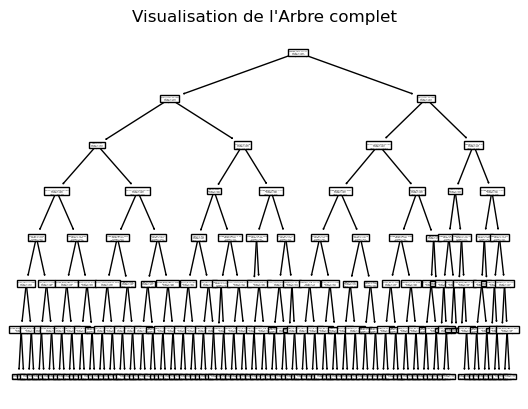

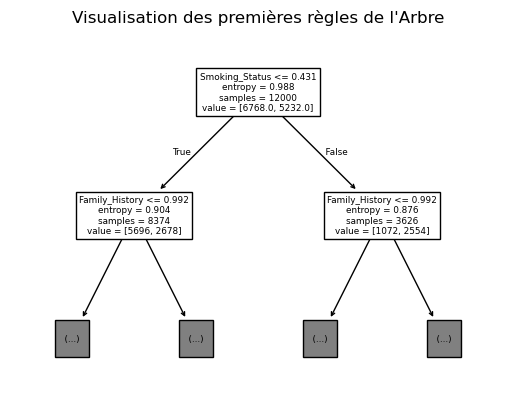

In [48]:
from sklearn.tree import plot_tree

# Affichage de l'arbre entier
plot_tree(treeOpt.best_estimator_,feature_names=df_cls.columns.tolist())
plt.title("Visualisation de l'Arbre complet")
plt.show()


# Affichage du début de l'arbre
plot_tree(treeOpt.best_estimator_,feature_names=df_cls.columns.tolist(), max_depth=1)
plt.title("Visualisation des premières règles de l'Arbre")
plt.show()

#### III. b) Random Forest

In [68]:
from sklearn.ensemble import RandomForestClassifier 

param=[{"max_features":list(range(2,10,1))}]
rf= GridSearchCV(RandomForestClassifier(n_estimators=100),param,cv=10,n_jobs=-1)
rfOpt=rf.fit(Xr_train_c, y_train_c)

Meilleure profondeur (Random Forest): 5
Accuracy CV (train, random Forest): 72.8167%


In [30]:
# Prédictions
y_pred_rf = rfOpt.predict(Xr_test_c)

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_rf,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleurs hyperparamètres (Arbre): {rfOpt.best_params_}")
print(f"Accuracy CV (train, Arbre): {rfOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, Arbre) : {accuracy_score(y_test_c, y_pred_rf)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_rf)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_rf)*100:.4f}%")

Heart_Disease_Risk     0    1
row_0                        
0                   1378  502
1                    314  806


Smoking_Status 0.10514344315752043
Fasting_Blood_Sugar 0.07669695173975109
Systolic_BP 0.07585436771456928
Age 0.07401935505224938
BMI 0.07347988177193128
Weight_kg 0.07301306394139898
Cholesterol_Total 0.07157708858702283
Height_cm 0.06952997548245095
Cholesterol_LDL 0.06841141890364122
Diastolic_BP 0.06454412164085789
Cholesterol_HDL 0.05829501457597619
Stress_Level 0.05025196143169282
Physical_Activity_Level 0.03861611639488813
Sleep_Hours 0.035516801083551985
Family_History 0.03435013897827846
Alcohol_Consumption 0.01982903273183942
Gender 0.010871266812379628


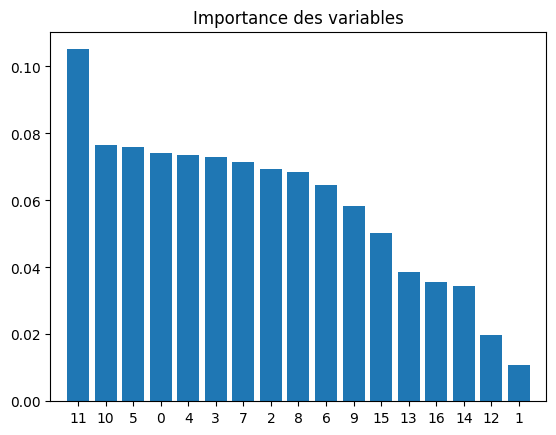

In [31]:
rf= RandomForestClassifier(n_estimators=100,max_features=2)
rfFit=rf.fit(Xr_train_c, y_train_c)
# Importance décroissante des variables
importances = rfFit.feature_importances_
indices = np.argsort(importances)[::-1]
for f in range(Xr_train_c.shape[1]):
    print(df_cls.columns[indices[f]], importances[indices[f]])


plt.figure()
plt.title("Importance des variables")
plt.bar(range(Xr_train_c.shape[1]), importances[indices]);
plt.xticks(range(Xr_train_c.shape[1]), indices);
plt.xlim([-1, Xr_train_c.shape[1]]);
plt.show()

#### III. c) Boosting

In [51]:
#Boosting
from sklearn.ensemble import GradientBoostingClassifier

param = {"n_estimators": [50, 100, 200], "max_depth": [2, 3, 4], "learning_rate": [0.05, 0.1, 0.2]}
gb = GridSearchCV(GradientBoostingClassifier(), param, cv=5, n_jobs=-1, verbose=1)
gbOpt = gb.fit(Xr_train_c, y_train_c)

print(f"Meilleurs hyperparamètres : {gbOpt.best_params_}")
print(f"Accuracy CV (train) : {gbOpt.best_score_*100:.4f}%")

y_pred_gb = gbOpt.predict(Xr_test_c)
print(f"Accuracy test : {accuracy_score(y_test_c, y_pred_gb)*100:.4f}%")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Meilleurs hyperparamètres : {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}
Accuracy CV (train) : 73.6250%
Accuracy test : 72.7333%


In [57]:
#XGBoosting
from xgboost import XGBClassifier

param = {"n_estimators": [100, 200], "max_depth": [3, 5], "learning_rate": [0.05, 0.1]}
xgb = GridSearchCV(XGBClassifier(eval_metric='logloss', random_state=seed), param, cv=5, n_jobs=-1)
xgbOpt = xgb.fit(Xr_train_c, y_train_c)

print(f"Meilleurs hyperparamètres : {xgbOpt.best_params_}")
print(f"Accuracy CV (train) : {xgbOpt.best_score_*100:.4f}%")

y_pred_xgb = xgbOpt.predict(Xr_test_c)
print(f"Accuracy test : {accuracy_score(y_test_c, y_pred_gb)*100:.4f}%")

ModuleNotFoundError: No module named 'xgboost'

### IV. Neural Networks

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical

n_features = Xr_train_c.shape[1]
n_classes = 2


I0000 00:00:1778071937.354642    9085 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778071946.548353    9085 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778071991.300940    9085 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [41]:
keras_model = Sequential()
keras_model.add(Dense(5, input_dim=n_features, activation='sigmoid'))  #On choisit de mettre 5 hidden layers
keras_model.add(Dense(n_classes, activation='softmax'))

keras_model.compile(optimizer=SGD(learning_rate=0.3),
                    loss='categorical_crossentropy', metrics=['accuracy'])

history = keras_model.fit(Xr_train_c, to_categorical(y_train_c), epochs=15, batch_size=32, validation_data = (Xr_test_c, to_categorical(y_test_c)))

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7278 - loss: 0.5453 - val_accuracy: 0.7347 - val_loss: 0.5374
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7369 - loss: 0.5330 - val_accuracy: 0.7267 - val_loss: 0.5384
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7356 - loss: 0.5327 - val_accuracy: 0.7263 - val_loss: 0.5441
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7339 - loss: 0.5320 - val_accuracy: 0.7363 - val_loss: 0.5335
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7377 - loss: 0.5330 - val_accuracy: 0.7353 - val_loss: 0.5335
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7365 - loss: 0.5309 - val_accuracy: 0.7263 - val_loss: 0.5403
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7379 - loss: 0.5314 - val_accuracy: 0.7347 - val_loss: 0.5342
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7393 - loss: 0.5312 - val_accuracy: 0.

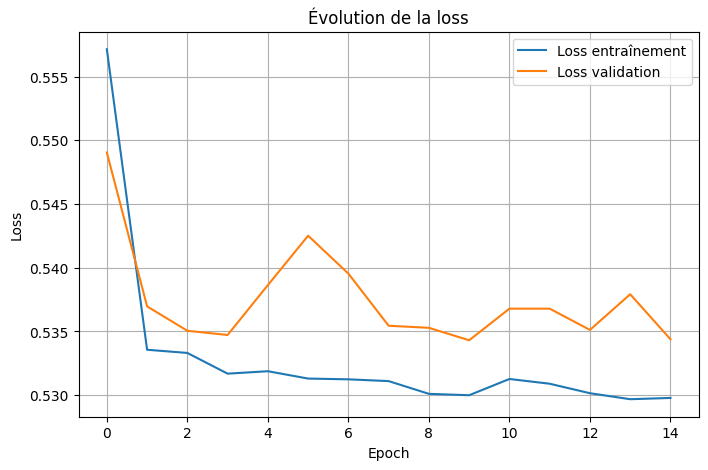

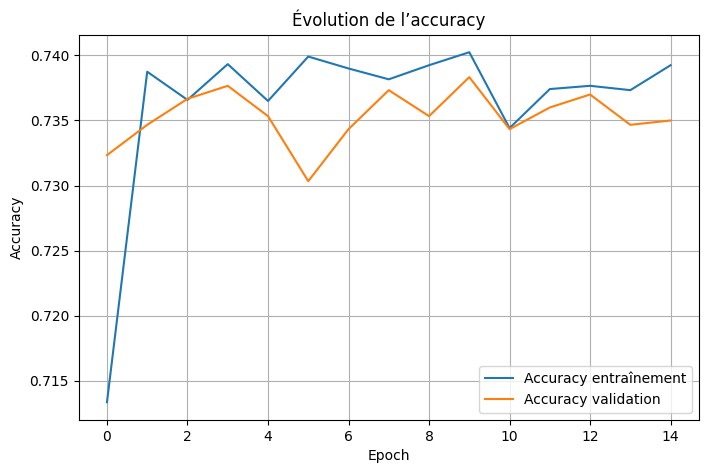

In [38]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Loss entraînement')
plt.plot(history.history['val_loss'], label='Loss validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Évolution de la loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Accuracy entraînement')
plt.plot(history.history['val_accuracy'], label='Accuracy validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Évolution de l’accuracy')
plt.legend()
plt.grid(True)
plt.show()


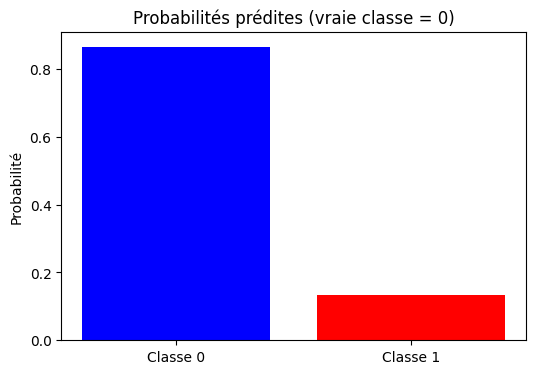

In [39]:
sample_idx = 42

probabilities = keras_model.predict(Xr_test_c, verbose=0)[sample_idx]

plt.figure(figsize=(6,4))
plt.bar([0,1], probabilities, color=["blue","red"])
plt.xticks([0,1], ["Classe 0", "Classe 1"])
plt.title(f"Probabilités prédites (vraie classe = {y_test_c.iloc[sample_idx]})")
plt.ylabel("Probabilité")
plt.show()



In [40]:
#On veut savoir combien mettre de hidden layers
results_mean = []
results_std = []
hidden_list = range(1, 10)

for n_hidden in hidden_list:
    accuracies = []
    
    for i in range(10):
        keras_model = Sequential()
        keras_model.add(Dense(n_hidden, input_dim=n_features, activation='sigmoid'))
        keras_model.add(Dense(n_classes, activation='softmax'))

        keras_model.compile(optimizer=SGD(learning_rate=0.3),
                            loss='categorical_crossentropy',
                            metrics=['accuracy'])

        keras_model.fit(Xr_train_c, to_categorical(y_train_c),
                        epochs=15, batch_size=32, verbose=0,
                        validation_data=(Xr_test_c, to_categorical(y_test_c)))

        _, acc = keras_model.evaluate(Xr_test_c, to_categorical(y_test_c), verbose=0)  #On récupère la val_accuracy du modele
        accuracies.append(acc)

    mean_acc = np.mean(accuracies)
    std_acc = np.std(accuracies)

    results_mean.append(mean_acc)
    results_std.append(std_acc)

    print(f"{n_hidden} neurones : accuracy moyenne = {mean_acc:.4f}, écart-type = {std_acc:.4f}")


/home/portapia/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


KeyboardInterrupt: 

In [34]:
plt.figure(figsize=(10,5))
plt.errorbar(hidden_list, results_mean, yerr=results_std, fmt='-o')
plt.xlabel("Nombre de neurones cachés")
plt.ylabel("Accuracy moyenne (± écart-type)")
plt.title("Performance du réseau en fonction du nombre de neurones cachés")
plt.grid(True)
plt.show()


NameError: name 'hidden_list' is not defined

<Figure size 1000x500 with 0 Axes>

### V. Comparaison des modèles

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step


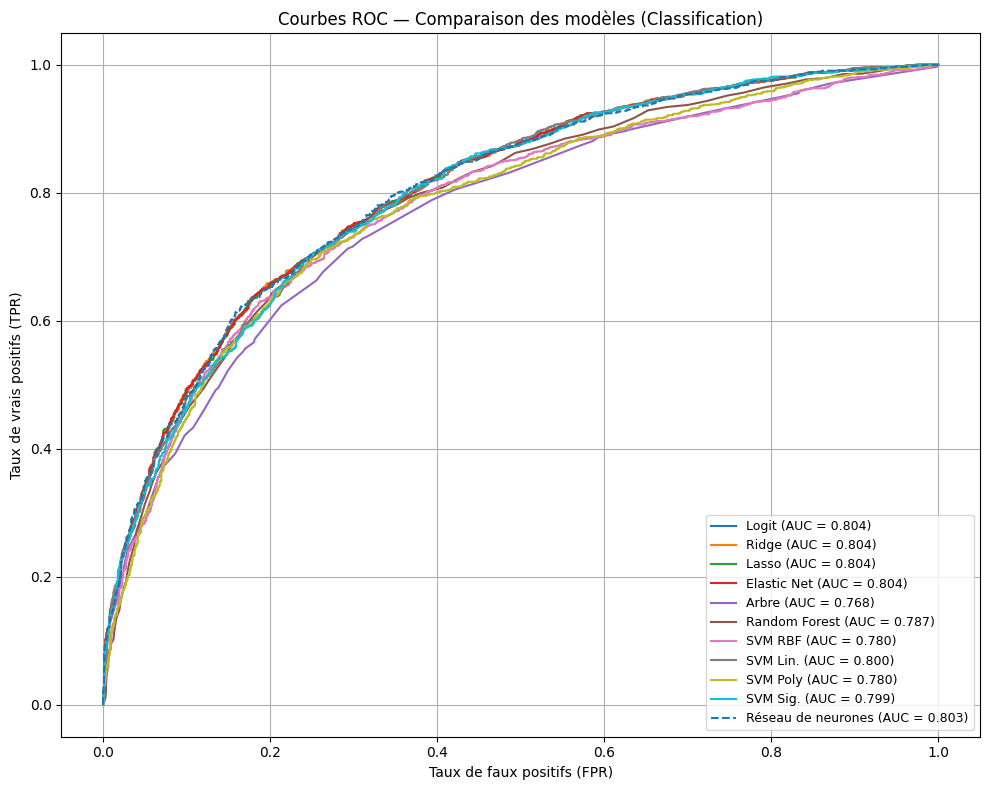

In [43]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

#Models that directly give predict_proba : LogisticRegression, Ridge, Lasso, ElasticNet, RandomForest, DecisionTree

models_proba = {
    "Logit":        logitOpt.best_estimator_,
    "Ridge":        ridgeOpt.best_estimator_,
    "Lasso":        lassoOpt.best_estimator_,
    "Elastic Net":  elaOpt.best_estimator_,
    "Arbre":        treeOpt.best_estimator_,
    "Random Forest": rfOpt.best_estimator_,
}

#SVM: need to refit with probability=True (SVMs do NOT expose predict_proba by default, it costs extra compute)
from sklearn.svm import SVC

svm_rbf_prob  = SVC(kernel="rbf",     C=svmOpt.best_params_['C'],     probability=True)
svm_lin_prob  = SVC(kernel="linear",  C=svm_lOpt.best_params_['C'],   probability=True)
svm_poly_prob = SVC(kernel="poly",    C=svm_pOpt.best_params_['C'],   probability=True)
svm_sig_prob  = SVC(kernel="sigmoid", C=svm_sOpt.best_params_['C'],   probability=True)

for name, m in [("SVM RBF", svm_rbf_prob), ("SVM Lin.", svm_lin_prob),
                ("SVM Poly", svm_poly_prob), ("SVM Sig.", svm_sig_prob)]:
    m.fit(Xr_train_c, y_train_c)
    models_proba[name] = m

#Predict pour le NN
nn_probs = keras_model.predict(Xr_test_c)[:, 1]  # probability of class 1

#PLot
plt.figure(figsize=(10, 8))

for name, model in models_proba.items():
    probs = model.predict_proba(Xr_test_c)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_c, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# Neural network
fpr_nn, tpr_nn, _ = roc_curve(y_test_c, nn_probs)
auc_nn = auc(fpr_nn, tpr_nn)
plt.plot(fpr_nn, tpr_nn, label=f"Réseau de neurones (AUC = {auc_nn:.3f})", linestyle='--')


plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbes ROC — Comparaison des modèles (Classification)")
plt.legend(loc="lower right", fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()


#Peut etre mettre d'abord les ROC pour chaque type, puis on choisit la meilleure par caté et on affiche leur ROC sur un autre graphe

## B. Modèles de régression

### I. Modèles linéaires

In [84]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet   #On importe des régresseurs qui existent deja
from sklearn.metrics import mean_squared_error, r2_score

#pas de reg log car c'est pas de la classif mais de la reg que l'on fait

param = {"alpha": [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 20]}

# Ridge
ridge_r = GridSearchCV(Ridge(), param, cv=5, n_jobs=-1)
ridge_r.fit(Xr_train_r, y_train_r)
prev = ridge_r.predict(Xr_test_r)
print("RIDGE")
print(f"Meilleur alpha (Ridge): {ridge_r.best_params_['alpha']}")
print(f"MSE = {mean_squared_error(y_test_r, prev):.4f}")
print(f"R²  = {r2_score(y_test_r, prev):.4f}")
print("\n")

# Lasso
lasso_r = GridSearchCV(Lasso(), param, cv=5, n_jobs=-1)
lasso_r.fit(Xr_train_r, y_train_r)
prev = lasso_r.predict(Xr_test_r)
print("Lasso")
print(f"Meilleur alpha (Lasso): {lasso_r.best_params_['alpha']}")
print(f"MSE = {mean_squared_error(y_test_r, prev):.4f}")
print(f"R²  = {r2_score(y_test_r, prev):.4f}")
print("\n")

# ElasticNet
param_ela = {"alpha": [0.01, 0.1, 1, 5], "l1_ratio": [0.2, 0.5, 0.8]}
ela_r = GridSearchCV(ElasticNet(), param_ela, cv=5, n_jobs=-1)
ela_r.fit(Xr_train_r, y_train_r)
prev = ela_r.predict(Xr_test_r)
print("Elastic Net")
print(f"Meilleur alpha (Elastic Net): {ela_r.best_params_['alpha']}")
print(f"MSE = {mean_squared_error(y_test_r, prev):.4f}")
print(f"R²  = {r2_score(y_test_r, prev):.4f}")

RIDGE
Meilleur alpha (Ridge): 20
MSE = 95.7386
R²  = 0.6944


Lasso
Meilleur alpha (Lasso): 0.1
MSE = 95.7145
R²  = 0.6945


Elastic Net
Meilleur alpha (Elastic Net): 0.01
MSE = 95.7429
R²  = 0.6944


### II. Support Vector

#### II. a) SVM avec kernel RBF

In [85]:
from sklearn.svm import SVR

param = {'C': [0.1, 1, 10, 50], 'epsilon': [0.1, 0.5, 1.0]}
svr_rbf= GridSearchCV(SVR(kernel="rbf"),param,cv=10,n_jobs=-1)
svrOpt_rbf=svr_rbf.fit(Xr_train_r, y_train_r)
# paramètre optimal
print(f"Meilleurs hyperparamètres SVR: {svrOpt_rbf.best_params_}")
print(f"R² CV (train): {svrOpt_rbf.best_score_:.4f}")

Meilleurs hyperparamètres SVR: {'C': 10, 'epsilon': 1.0}
R² CV (train): 0.6588


#### II. b) SVM avec kernel linéaire

In [86]:
param = {'C': [0.1, 1, 10, 50], 'epsilon': [0.1, 0.5, 1.0]}
svr_lin= GridSearchCV(SVR(kernel="linear"),param,cv=10,n_jobs=-1)
svrOpt_lin=svr_lin.fit(Xr_train_r, y_train_r)
# paramètre optimal
print(f"Meilleurs hyperparamètres SVR: {svrOpt_lin.best_params_}")
print(f"R² CV (train): {svrOpt_lin.best_score_:.4f}")

Meilleurs hyperparamètres SVR: {'C': 1, 'epsilon': 1.0}
R² CV (train): 0.6856


#### II. c) SVM avec kernel polynomial

In [87]:
param = {'C': [0.1, 1, 10, 50], 'epsilon': [0.1, 0.5, 1.0]}
svr_p= GridSearchCV(SVR(kernel="poly"),param,cv=10,n_jobs=-1)
svrOpt_p=svr_p.fit(Xr_train_r, y_train_r)
# paramètre optimal
print(f"Meilleurs hyperparamètres SVR: {svrOpt_p.best_params_}")
print(f"R² CV (train): {svrOpt_p.best_score_:.4f}")

Meilleurs hyperparamètres SVR: {'C': 50, 'epsilon': 1.0}
R² CV (train): 0.6494


#### II. d) SVM avec kernel sigmoid

In [88]:
param = {'C': [0.1, 1, 10, 50], 'epsilon': [0.1, 0.5, 1.0]}
svr_s= GridSearchCV(SVR(kernel="sigmoid"),param,cv=10,n_jobs=-1)
svrOpt_s=svr_s.fit(Xr_train_r, y_train_r)
# paramètre optimal
print(f"Meilleurs hyperparamètres SVR: {svrOpt_s.best_params_}")
print(f"R² CV (train): {svrOpt_s.best_score_:.4f}")

Meilleurs hyperparamètres SVR: {'C': 0.1, 'epsilon': 0.5}
R² CV (train): 0.6595


### III. Arbre optimal, Random Forest, Boosting

#### III. a) Arbre optimal

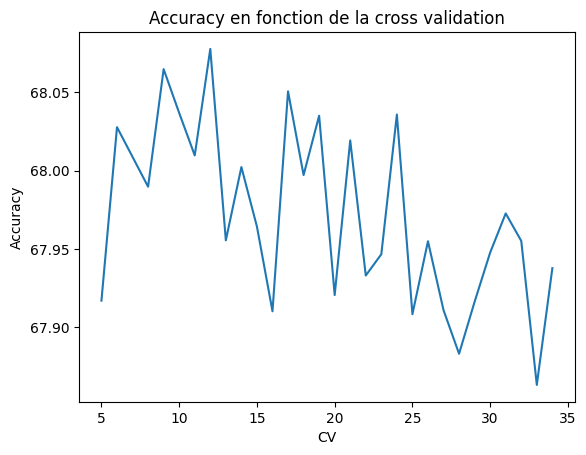

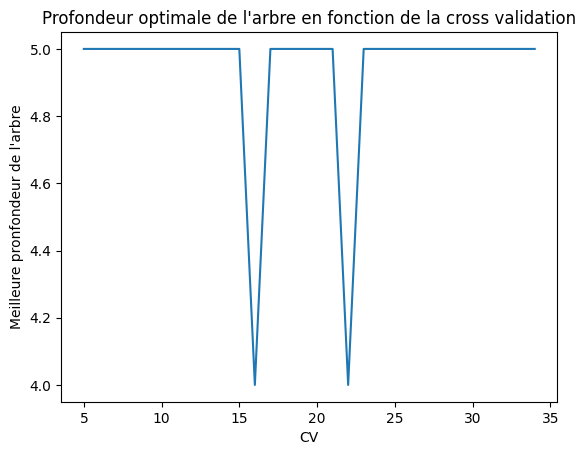

In [89]:
from sklearn.tree import DecisionTreeRegressor
cv_val = []
acc = []
dep = []

for cv in range(5,35):
    cv_val.append(cv)
    # Optimisation de la profondeur de l'arbre
    param=[{"max_depth":list(range(2,15))}]
    tree= GridSearchCV(DecisionTreeRegressor(),param,cv=cv,n_jobs=-1)
    treeOpt=tree.fit(Xr_train_r, y_train_r)
    acc.append(treeOpt.best_score_*100)
    dep.append(treeOpt.best_params_['max_depth'])
    
    #print(f"Meilleure profondeur (Arbre Optimal): {treeOpt.best_params_['max_depth']}")
    #print(f"Accuracy CV (train, Arbre Optimal): {treeOpt.best_score_*100:.4f}%")
plt.plot(cv_val,acc)
plt.xlabel("CV")
plt.ylabel("Accuracy")
plt.title("Accuracy en fonction de la cross validation")
plt.show()

plt.plot(cv_val,dep)
plt.xlabel("CV")
plt.ylabel("Meilleure pronfondeur de l'arbre")
plt.title("Profondeur optimale de l'arbre en fonction de la cross validation")
plt.show()

In [90]:
# Optimisation de la profondeur de l'arbre
param=[{"max_depth":list(range(2,15))}]
tree= GridSearchCV(DecisionTreeRegressor(),param,cv=10,n_jobs=-1)
treeOpt=tree.fit(Xr_train_r, y_train_r)

    
print(f"Meilleure profondeur (Arbre Optimal): {treeOpt.best_params_['max_depth']}")
print(f"Accuracy CV (train, Arbre Optimal): {treeOpt.best_score_*100:.4f}%")

Meilleure profondeur (Arbre Optimal): 5
Accuracy CV (train, Arbre Optimal): 68.0367%


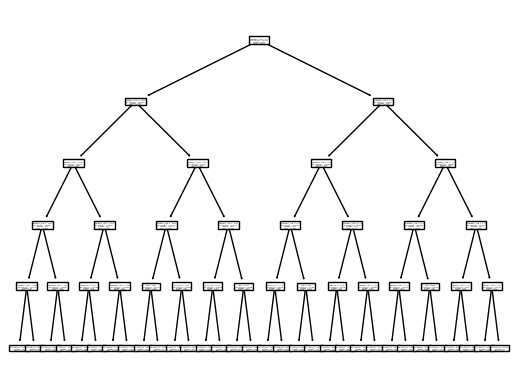

In [91]:
from sklearn.tree import plot_tree

treeG_r=DecisionTreeRegressor(max_depth=treeOpt.best_params_['max_depth'])
treeG_r.fit(Xr_train_r,y_train_r)
plot_tree(treeG_r,feature_names = X_train_r.columns.tolist());
plt.show()

#### III. b) Random Forest

In [92]:
from sklearn.ensemble import RandomForestRegressor

param=[{"max_features":list(range(2,10,1))}]
rf_r= GridSearchCV(RandomForestRegressor(n_estimators=100),param,cv=10,n_jobs=-1)
rfOpt_r=rf_r.fit(Xr_train_r, y_train_r)

print(f"Meilleure profondeur (Random Forest): {rfOpt_r.best_params_['max_features']}")
print(f"Accuracy CV (train, Random Forest): {rfOpt_r.best_score_*100:.4f}%")

Meilleure profondeur (Random Forest): 9
Accuracy CV (train, Random Forest): 67.0722%


Cholesterol_Total 0.4814707992800307
Age 0.08336978431261266
BMI 0.054146900045715964
Weight_kg 0.05294395625190392
Height_cm 0.04821433661932121
Systolic_BP 0.04778056625924995
Fasting_Blood_Sugar 0.04507351819494561
Diastolic_BP 0.04310998807814651
Cholesterol_HDL 0.03985334644295743
Stress_Level 0.03022776676400022
Sleep_Hours 0.023425479402353296
Physical_Activity_Level 0.017964849114697822
Alcohol_Consumption 0.012249006273410985
Smoking_Status 0.007696166518496616
Gender 0.006402822460364838
Family_History 0.006070713981792222


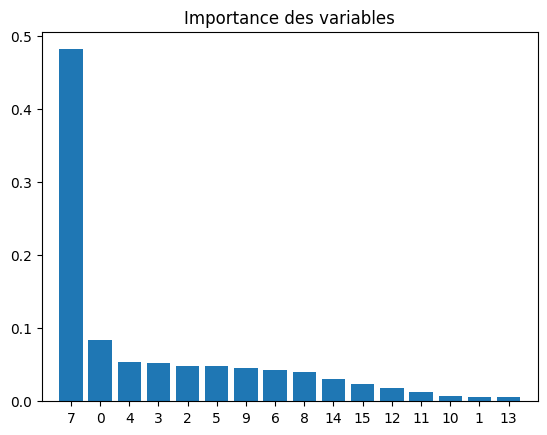

In [93]:
rf= RandomForestRegressor(n_estimators=100,max_features=2)
rfFit=rf.fit(Xr_train_r, y_train_r)
# Importance décroissante des variables
importances = rfFit.feature_importances_
indices = np.argsort(importances)[::-1]
for f in range(Xr_train_r.shape[1]):
    print(X_train_r.columns.tolist()[indices[f]], importances[indices[f]])


plt.figure()
plt.title("Importance des variables")
plt.bar(range(Xr_train_r.shape[1]), importances[indices]);
plt.xticks(range(Xr_train_r.shape[1]), indices);
plt.xlim([-1, Xr_train_r.shape[1]]);
plt.show()

#### III. c) Boosting

In [94]:
from sklearn.ensemble import GradientBoostingRegressor

param = {"n_estimators": [50, 100, 200], "max_depth": [2, 3, 4], "learning_rate": [0.05, 0.1, 0.2]}
gb_r = GridSearchCV(GradientBoostingRegressor(), param, cv=5, n_jobs=-1, verbose=1)
gbOpt_r = gb_r.fit(Xr_train_r, y_train_r)

print(f"Meilleurs hyperparamètres : {gbOpt_r.best_params_}")
print(f"Accuracy CV (train) : {gbOpt_r.best_score_*100:.4f}%")

y_pred_gb = gbOpt_r.predict(Xr_test_r)
print(f"R² test : {r2_score(y_test_r, y_pred_gb)*100:.4f}%")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Meilleurs hyperparamètres : {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}
Accuracy CV (train) : 68.3730%
R² test : 69.1166%


### IV. Neuronal Networks

In [78]:
from tensorflow.keras.metrics import MeanSquaredError

n_features = Xr_train_r.shape[1]

keras_model_r = Sequential()
keras_model_r.add(Dense(5, input_dim=n_features, activation='sigmoid'))
keras_model_r.add(Dense(1, activation='linear'))  # sortie régression

keras_model_r.compile(optimizer=SGD(learning_rate=0.3),
                    loss='mse',
                    metrics=[MeanSquaredError()])  #Voir s'il faut pas changer en R² vu qu'apres on compare avec R²

history = keras_model_r.fit(
    Xr_train_r, y_train_r,
    epochs=20,
    batch_size=32,
    validation_data=(Xr_test_r, y_test_r)
)

Epoch 1/20
  1/375 ━━━━━━━━━━━━━━━━━━━━ 43s 116ms/step - loss: 20270.4336 - mean_squared_error: 20270.4336

/home/portapia/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 290.0069 - mean_squared_error: 290.0069 - val_loss: 174.6313 - val_mean_squared_error: 174.6313
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 858us/step - loss: 176.3285 - mean_squared_error: 176.3285 - val_loss: 167.2104 - val_mean_squared_error: 167.2104
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step - loss: 166.6859 - mean_squared_error: 166.6859 - val_loss: 156.0707 - val_mean_squared_error: 156.0707
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step - loss: 158.8282 - mean_squared_error: 158.8282 - val_loss: 166.1418 - val_mean_squared_error: 166.1418
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 833us/step - loss: 155.9433 - mean_squared_error: 155.9433 - val_loss: 146.4626 - val_mean_squared_error: 146.4626
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step - loss: 154.3006 - mean_squared_error: 154.3006 - val_loss: 152.9958 - val_mean_squared_error: 152.9958
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 807us/step - loss: 153

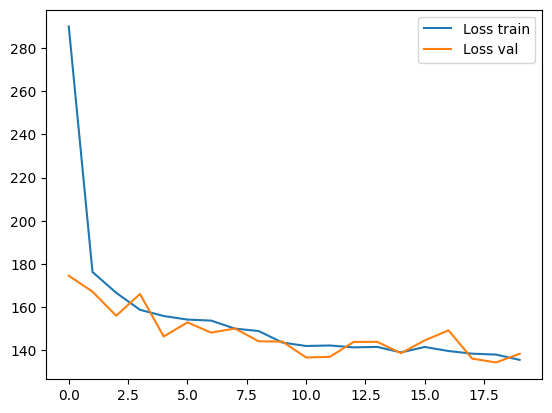

In [79]:
plt.plot(history.history['loss'], label='Loss train')
plt.plot(history.history['val_loss'], label='Loss val')
plt.legend()
plt.show()

In [76]:
from sklearn.metrics import r2_score

results_mean = []
results_std = []
hidden_list = range(1, 10)

for n_hidden in hidden_list:
    r2_scores = []
    
    for i in range(10):
        keras_model = Sequential()
        keras_model.add(Dense(n_hidden, input_dim=n_features, activation='sigmoid'))
        keras_model.add(Dense(1, activation='linear'))  # sortie régression

        keras_model.compile(optimizer=SGD(learning_rate=0.3),
                            loss='mse')  # la loss reste MSE, mais la métrique sera R²

        keras_model.fit(Xr_train_r, y_train_r,
                        epochs=20, batch_size=32, verbose=0,
                        validation_data=(Xr_test_r, y_test_r))

        # prédictions sur le test
        y_pred = keras_model.predict(Xr_test_r, verbose=0)

        # calcul du R²
        r2 = r2_score(y_test_r, y_pred)
        r2_scores.append(r2)

    results_mean.append(np.mean(r2_scores))
    results_std.append(np.std(r2_scores))

    print(f"{n_hidden} neurones : R² moyen = {np.mean(r2_scores):.4f}, écart-type = {np.std(r2_scores):.4f}")


#Sélectionner le meilleur n_hidden et faire le fit dessus pour apres pouvoir le comparer (cf cellule comparaison)
keras_modelOpt_r = ...


/home/portapia/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/portapia/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/portapia/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=act

1 neurones : R² moyen = 0.4049, écart-type = 0.0189


/home/portapia/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/portapia/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/portapia/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=act

2 neurones : R² moyen = 0.5266, écart-type = 0.0193


/home/portapia/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/portapia/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/portapia/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=act

...

7 neurones : R² moyen = 0.5392, écart-type = 0.0623


/home/portapia/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/portapia/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/portapia/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=act

8 neurones : R² moyen = 0.4660, écart-type = 0.0816


/home/portapia/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/portapia/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/portapia/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=act

9 neurones : R² moyen = 0.5043, écart-type = 0.0610


### V. Comparaison des modèles !!!!!!

In [99]:
keras_modelOpt_r = keras_model_r

# Évaluation finale sur le test set
from sklearn.metrics import mean_absolute_error


models_reg = {
    'Ridge': (ridge_r.best_estimator_, Xr_test_r),
    'Lasso': (lasso_r.best_estimator_, Xr_test_r),
    'ElasticNet': (ela_r.best_estimator_,    Xr_test_r),
    'SVR (Linéaire)': (svrOpt_lin.best_estimator_,   Xr_test_r),
    'Decision Tree': (treeG_r,  Xr_test_r),
    'Random Forest': (rfOpt_r.best_estimator_,  Xr_test_r),
    'Gradient Boosting': (gbOpt_r.best_estimator_,  Xr_test_r),
    'MLP': (keras_modelOpt_r, Xr_test_r),
}

results_reg = {}
for name, (model, X_t) in models_reg.items():
    y_pred = model.predict(X_t)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    mae  = mean_absolute_error(y_test_r, y_pred)
    r2   = r2_score(y_test_r, y_pred)
    results_reg[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}

results_df_reg = pd.DataFrame(results_reg).T.round(4)
results_df_reg = results_df_reg.sort_values('R²', ascending=False)
print(results_df_reg.to_string())

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step
                      RMSE     MAE      R²
Lasso               9.7834  7.7193  0.6945
Ridge               9.7846  7.7257  0.6944
ElasticNet          9.7848  7.7250  0.6944
SVR (Linéaire)      9.7903  7.7336  0.6941
Gradient Boosting   9.8369  7.7687  0.6912
Decision Tree       9.8875  7.8002  0.6880
Random Forest      10.0478  7.9461  0.6778
MLP                11.4046  9.0029  0.5849


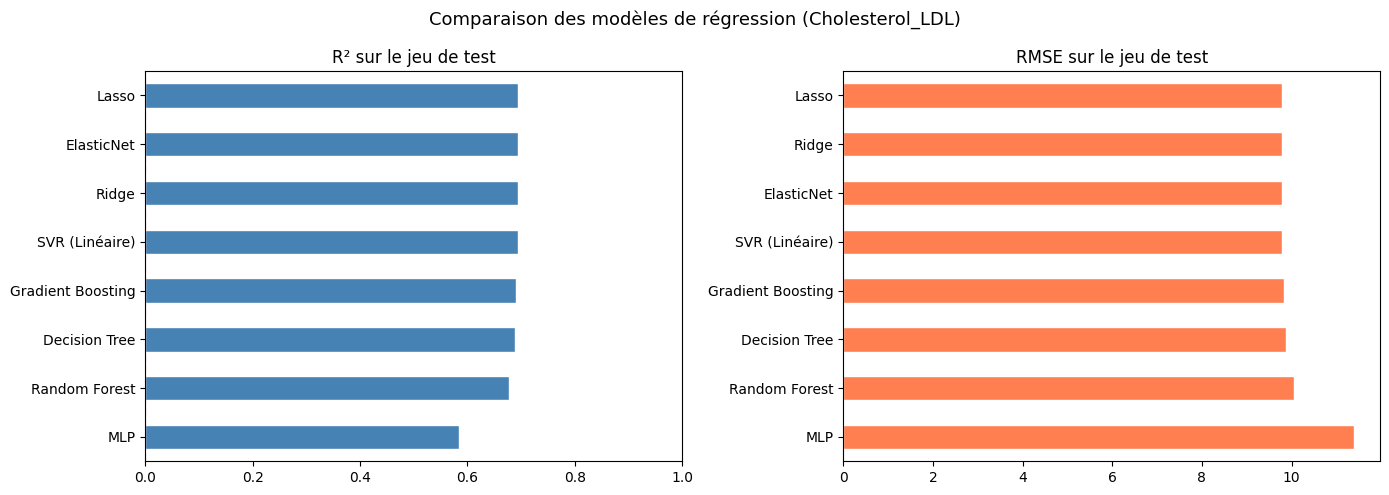

In [100]:
# Graphique comparatif (régression)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df_reg['R²'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('R² sur le jeu de test'); axes[0].set_xlim(0, 1.0)
axes[0].axvline(0, color='red', linestyle='--')

results_df_reg['RMSE'].sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('RMSE sur le jeu de test')

plt.suptitle('Comparaison des modèles de régression (Cholesterol_LDL)', fontsize=13)
plt.tight_layout()
plt.savefig('reg_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

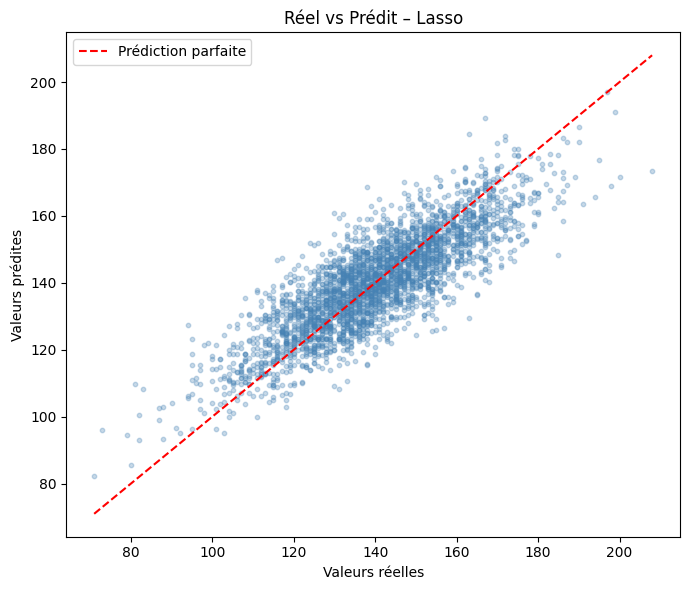

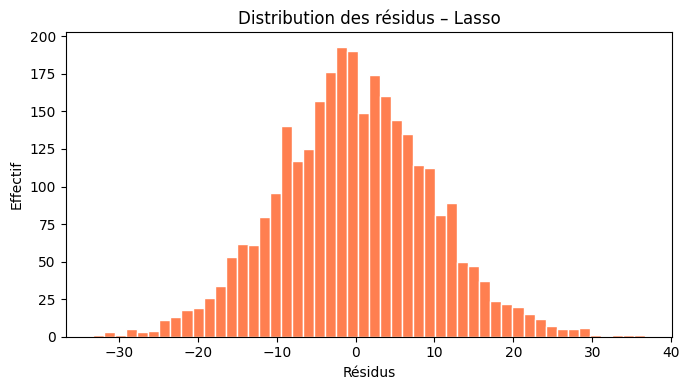

In [101]:
# Graphe valeurs prédites vs réelles du meilleur modèle
best_reg_name = results_df_reg.index[0]
best_reg_model, best_reg_Xt = models_reg[best_reg_name]
y_pred_best_r = best_reg_model.predict(best_reg_Xt)

plt.figure(figsize=(7, 6))
plt.scatter(y_test_r, y_pred_best_r, alpha=0.3, s=10, color='steelblue')
mn, mx = y_test_r.min(), y_test_r.max()
plt.plot([mn, mx], [mn, mx], 'r--', label='Prédiction parfaite')
plt.xlabel('Valeurs réelles'); plt.ylabel('Valeurs prédites')
plt.title(f'Réel vs Prédit – {best_reg_name}')
plt.legend()
plt.tight_layout()
plt.savefig('reg_pred_vs_real.png', dpi=100, bbox_inches='tight')
plt.show()

# Résidus
residuals = y_test_r - y_pred_best_r
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=50, color='coral', edgecolor='white')
plt.xlabel('Résidus'); plt.ylabel('Effectif')
plt.title(f'Distribution des résidus – {best_reg_name}')
plt.tight_layout()
plt.savefig('reg_residuals.png', dpi=100, bbox_inches='tight')
plt.show()

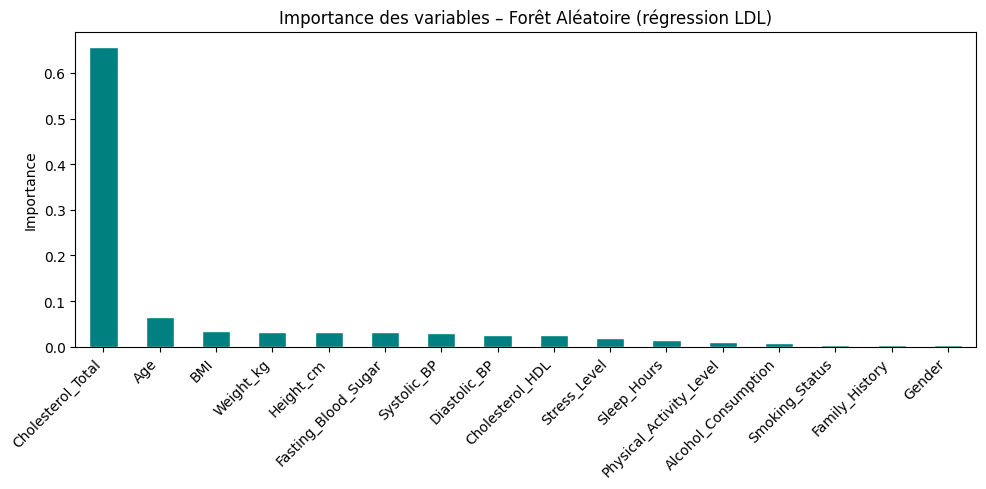

Top 5 : {'Cholesterol_Total': 0.6572012741419112, 'Age': 0.0655073661324183, 'BMI': 0.03447565835964542, 'Weight_kg': 0.03300846099890151, 'Height_cm': 0.03265485093339641}


In [103]:
# Importance des variables pour la régression (RF)
rf_r_best = rf_r.best_estimator_
feat_imp_r = pd.Series(rf_r_best.feature_importances_, index=features_reg).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp_r.plot(kind='bar', color='teal', edgecolor='white')
plt.title('Importance des variables – Forêt Aléatoire (régression LDL)')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feat_imp_reg.png', dpi=100, bbox_inches='tight')
plt.show()

print("Top 5 :", feat_imp_r.head(5).to_dict())